<a href="https://colab.research.google.com/github/mohammeddd7774-ux/car---bike--dataset/blob/main/Car_Bike_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [11]:
train_dir = '/content/drive/MyDrive/Car-Bike-Dataset/train'
test_dir = '/content/drive/MyDrive/Car-Bike-Dataset/test'

In [12]:
import os
print(len(os.listdir('/content/drive/MyDrive/Car-Bike-Dataset/train/Car')))
print(len(os.listdir('/content/drive/MyDrive/Car-Bike-Dataset/train/Bike')))
print(len(os.listdir('/content/drive/MyDrive/Car-Bike-Dataset/test/Car')))
print(len(os.listdir('/content/drive/MyDrive/Car-Bike-Dataset/test/Bike')))

2000
2000
2000
2000


In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create ImageDataGenerator for training set
train_datagen = ImageDataGenerator(
    rescale=1./255, #normalisation / feature scaling
    validation_split=0.2  # Split 20% of the images for validation
)

# Load and prepare training data
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',
    subset='training'  # Specify 'training' for the training set
)

# Create ImageDataGenerator for validation set
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # Note: Using the same validation split as in the training set
)

# Load and prepare validation data
validation_data = validation_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',
    subset='validation'  # Specify 'validation' for the validation set
)

Found 3200 images belonging to 2 classes.
Found 800 images belonging to 2 classes.


In [14]:
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,UpSampling2D, Dropout

In [24]:
# create CNN model - custom-made

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))  # 32 filters
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu')) #feature reduction
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))  #output laye

In [25]:
from keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy']) #binary_crossentropy - binary classification

In [26]:
history = model.fit(train_data, epochs=5, validation_data=validation_data)

Epoch 1/5
 13/100 ━━━━━━━━━━━━━━━━━━━━ 11:51 8s/step - accuracy: 0.4756 - loss: 1.0070

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


100/100 ━━━━━━━━━━━━━━━━━━━━ 1021s 10s/step - accuracy: 0.6483 - loss: 0.6543 - val_accuracy: 0.8263 - val_loss: 0.3996
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 474s 5s/step - accuracy: 0.9143 - loss: 0.2292 - val_accuracy: 0.9125 - val_loss: 0.2301
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 459s 5s/step - accuracy: 0.9608 - loss: 0.1006 - val_accuracy: 0.9312 - val_loss: 0.1778
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 455s 5s/step - accuracy: 0.9821 - loss: 0.0514 - val_accuracy: 0.9112 - val_loss: 0.2625
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 466s 5s/step - accuracy: 0.9903 - loss: 0.0294 - val_accuracy: 0.9175 - val_loss: 0.2988


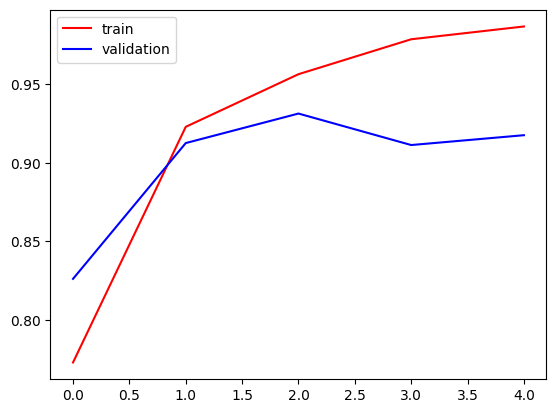

In [27]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

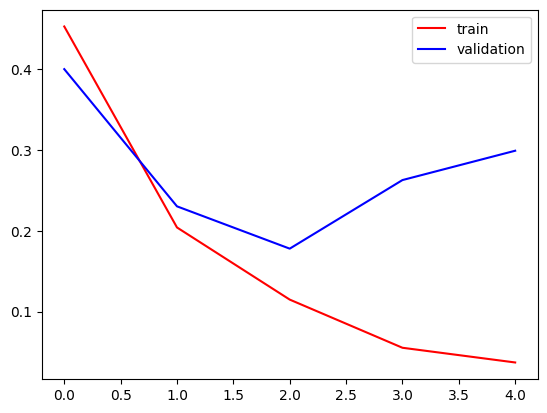

In [28]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [29]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary'
)

Found 4000 images belonging to 2 classes.


In [30]:
predictions = model.predict(test_data)

125/125 ━━━━━━━━━━━━━━━━━━━━ 500s 4s/step


In [31]:
from sklearn.metrics import confusion_matrix, classification_report


true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)


cm = confusion_matrix(true_labels, predicted_labels)


print("Confusion Matrix:")
print(cm)


print("Classification Report:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[1028  972]
 [ 978 1022]]
Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.51      0.51      2000
           1       0.51      0.51      0.51      2000

    accuracy                           0.51      4000
   macro avg       0.51      0.51      0.51      4000
weighted avg       0.51      0.51      0.51      4000



In [33]:
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))  # 32 filters
model.add(BatchNormalization())  # added to reduce overfitting
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())  # added to reduce overfitting
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())  # added to reduce overfitting
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu')) #feature reduction
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))  #output layer

In [34]:
from keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

In [35]:
history = model.fit(train_data, epochs=5, validation_data=validation_data)

Epoch 1/5
 13/100 ━━━━━━━━━━━━━━━━━━━━ 10:04 7s/step - accuracy: 0.6397 - loss: 5.0158

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


100/100 ━━━━━━━━━━━━━━━━━━━━ 711s 7s/step - accuracy: 0.7413 - loss: 2.6936 - val_accuracy: 0.4950 - val_loss: 7.6607
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 700s 7s/step - accuracy: 0.9055 - loss: 0.2928 - val_accuracy: 0.4600 - val_loss: 3.9143
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 703s 7s/step - accuracy: 0.9576 - loss: 0.1512 - val_accuracy: 0.5325 - val_loss: 12.1814
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 709s 7s/step - accuracy: 0.9357 - loss: 0.4921 - val_accuracy: 0.6562 - val_loss: 1.6455
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 703s 7s/step - accuracy: 0.9472 - loss: 0.2926 - val_accuracy: 0.8712 - val_loss: 0.4595


In [36]:
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary'
)

Found 4000 images belonging to 2 classes.


In [37]:
predictions = model.predict(test_data)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


125/125 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step


In [38]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming you have ground truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)  # Adjust the threshold as needed

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Print classification report
print("Classification Report after applying techniques to handle overfitting:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[ 976 1024]
 [ 964 1036]]
Classification Report after applying techniques to handle overfitting:
              precision    recall  f1-score   support

           0       0.50      0.49      0.50      2000
           1       0.50      0.52      0.51      2000

    accuracy                           0.50      4000
   macro avg       0.50      0.50      0.50      4000
weighted avg       0.50      0.50      0.50      4000



In [40]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten

resnet_model = Sequential()    #ResNet50 is a pre-trained model
pretrained_model = tf.keras.applications.ResNet50(include_top = False, #because i have my own image of a diff dimension
                                                input_shape = (256,256,3),
                                                pooling = 'max', classes = 2,
                                                weights = 'imagenet')
for layer in pretrained_model.layers:
    layer.trainable = False  #all layers in the Resnet50 is not trainable; keep those weights; I am going to add my own i/p and other layers

resnet_model.add(pretrained_model)
resnet_model.add(Flatten())
resnet_model.add(Dense(512, activation = 'relu'))
resnet_model.add(Dense(1, activation = 'sigmoid'))

In [41]:
from keras.optimizers import Adam
resnet_model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

In [42]:
history = resnet_model.fit(train_data, epochs=7, validation_data=validation_data)

Epoch 1/7
  9/100 ━━━━━━━━━━━━━━━━━━━━ 10:30 7s/step - accuracy: 0.4917 - loss: 4.6128

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


100/100 ━━━━━━━━━━━━━━━━━━━━ 882s 9s/step - accuracy: 0.6600 - loss: 2.0169 - val_accuracy: 0.8438 - val_loss: 0.3437
Epoch 2/7
100/100 ━━━━━━━━━━━━━━━━━━━━ 865s 9s/step - accuracy: 0.8477 - loss: 0.3429 - val_accuracy: 0.8587 - val_loss: 0.3158
Epoch 3/7
100/100 ━━━━━━━━━━━━━━━━━━━━ 908s 9s/step - accuracy: 0.8142 - loss: 0.4293 - val_accuracy: 0.8300 - val_loss: 0.3866
Epoch 4/7
100/100 ━━━━━━━━━━━━━━━━━━━━ 878s 9s/step - accuracy: 0.8810 - loss: 0.2726 - val_accuracy: 0.8550 - val_loss: 0.3617
Epoch 5/7
100/100 ━━━━━━━━━━━━━━━━━━━━ 872s 9s/step - accuracy: 0.8694 - loss: 0.2965 - val_accuracy: 0.8712 - val_loss: 0.2957
Epoch 6/7
100/100 ━━━━━━━━━━━━━━━━━━━━ 868s 9s/step - accuracy: 0.9068 - loss: 0.2228 - val_accuracy: 0.7375 - val_loss: 0.5883
Epoch 7/7
100/100 ━━━━━━━━━━━━━━━━━━━━ 867s 9s/step - accuracy: 0.8903 - loss: 0.2599 - val_accuracy: 0.8700 - val_loss: 0.3286


In [43]:
predictions = resnet_model.predict(test_data)

125/125 ━━━━━━━━━━━━━━━━━━━━ 878s 7s/step


In [44]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming you have ground truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)  # Adjust the threshold as needed

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Print classification report
print("Classification Report after applying techniques to handle overfitting:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[ 799 1201]
 [ 813 1187]]
Classification Report after applying techniques to handle overfitting:
              precision    recall  f1-score   support

           0       0.50      0.40      0.44      2000
           1       0.50      0.59      0.54      2000

    accuracy                           0.50      4000
   macro avg       0.50      0.50      0.49      4000
weighted avg       0.50      0.50      0.49      4000

